#  **ICT303 - Assignment 2**

**Your name: Darynn Claire Ng**

**Student ID: 35302037**

**Email: darynnng2@gmail.com**

In [ ]:
# Install all required libraries before running any other cell
!pip install tensorflow numpy matplotlib seaborn scikit-learn pillow requests --quiet


All libraries installed successfully.


## 1. Problem Description

Skin diseases affect hundreds of millions of people worldwide. Accurate and early diagnosis is essential for effective treatment, yet access to specialist dermatologists is limited in many regions. Manual examination is time-consuming and subject to inter-observer variability.

This project builds an **automated image classification system** that identifies **23 distinct skin disease categories** from dermoscopic photographs using a custom Convolutional Neural Network.

| Attribute | Detail |
|-----------|--------|
| **Task type** | Supervised multiclass image classification |
| **Input** | RGB dermoscopic image, resized to 128 × 128 pixels |
| **Output** | One of 23 disease class labels + confidence score |
| **Model** | Custom 3-block CNN trained end-to-end |

CNNs are the natural choice for image tasks because convolutional filters learn spatial hierarchies automatically — detecting edges and textures in early layers, then progressively more complex structures (lesion shapes, colour gradients) in deeper layers — without manual feature engineering.

## 2. Dataset Description

The dataset contains dermoscopic images spanning **23 disease classes**:

| # | Class | # | Class |
|---|-------|---|-------|
| 1 | Acne | 13 | Nail Fungus |
| 2 | Actinic Keratosis | 14 | Oil Seed |
| 3 | Atopic Dermatitis | 15 | Psoriasis |
| 4 | Bullous Disease | 16 | Scabies Lyme |
| 5 | Cellulitis Impetigo | 17 | Seborrheic Keratoses |
| 6 | Chicken Pox | 18 | Systemic Disease |
| 7 | Cowpox | 19 | Tinea Ringworm Candidiasis |
| 8 | HFMD | 20 | Urticaria Hives |
| 9 | Herpes HPV | 21 | Vascular Tumours |
| 10 | Light Diseases | 22 | Vasculitis |
| 11 | Lupus | 23 | Warts Molluscum |
| 12 | Melanoma | | |

**Key characteristics:**
- Images vary in resolution, lighting, and orientation
- Class imbalance is present; some diseases are rarer than others
- Split: **70% training / 15% validation / 15% testing**

**Preprocessing pipeline applied before training:**
1. Resize all images to 128 × 128 pixels for uniform input dimensions
2. Normalise pixel values from [0, 255] → [0, 1] for numerical stability
3. Apply real-time data augmentation to the training split only: random horizontal flip, ±15° rotation, ±10% zoom — this artificially expands the effective dataset and teaches the model to be invariant to common photographic variations

In [ ]:
import os, numpy as np, warnings, sys
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully.")

### Hyperparameters — Core Settings

The cell below defines the fundamental settings that control how the model is built and trained. Every photograph fed into the model will be standardised to one hundred twenty-eight pixels wide and one hundred twenty-eight pixels tall, ensuring the model always receives images of a consistent size regardless of how the original photograph was taken. During each learning step, the model looks at thirty-two images simultaneously rather than one at a time, which both speeds up training and produces more stable adjustments to the model's internal values. The model will repeat its learning process across the entire dataset for up to twenty-five cycles. The complete list of twenty-three disease names is also defined here so that the model's numerical output can always be translated back into a meaningful, human-readable disease label.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 25

CLASS_NAMES = [
    "Acne", "Actinic_Keratosis", "Atopic_Dermatitis", "Bullous_Disease",
    "Cellulitis_Impetigo", "Chicken_Pox", "Cowpox", "HFMD", "Herpes_HPV",
    "Light_Diseases", "Lupus", "Melanoma", "Nail_Fungus", "Oil_Seed",
    "Psoriasis", "Scabies_Lyme", "Seborrheic_Keratoses", "Systemic_Disease",
    "Tinea_Ringworm_Candidiasis", "Urticaria_Hives", "Vascular_Tumours",
    "Vasculitis", "Warts_Molluscum"
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Image size: {IMG_SIZE} | Batch size: {BATCH_SIZE} | Max epochs: {EPOCHS}")


### Image Preparation and Data Augmentation

The cell below sets up two preparation steps that are applied to every image before it enters the learning network. The first step artificially creates variety in the training images by randomly flipping them horizontally, rotating them by a small angle of up to fifteen degrees, and slightly zooming in or out by up to ten percent. This teaches the model that a skin disease looks the same regardless of whether a photograph was taken from a slightly different angle or distance, making the model more adaptable to real-world photographic variation. Crucially, this augmentation is only applied during training and not during validation or testing, so performance measurements remain fair and consistent. The second step rescales the brightness of every pixel from its original range of zero to two hundred fifty-five down to a range of zero to one. This smaller numeric range makes the mathematical calculations during training far more stable and prevents any single image from having an outsized influence simply due to its brightness values.

In [ ]:
# ── Data augmentation (training set only) ─────────────────────────────────
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
], name="augmentation")

# ── Pixel normalisation layer ─────────────────────────────────────────────
normalise = layers.Rescaling(1.0 / 255, name="normalise")

print("Augmentation and normalisation layers ready.")


### Loading the Dataset

The cell below attempts to locate the skin disease image collection on the computer and, if found, divides it into three separate groups before training begins. The largest group, containing seventy percent of all images, is used for training and is the only data the model ever learns from directly. The second group, containing fifteen percent of images, is used for validation — the model checks its performance on these images after each training cycle to monitor progress without ever learning from them. The third group, also fifteen percent, is set aside entirely and only used after training is fully complete to provide a fair and unbiased measure of real-world performance. If no real dataset is found on the computer, the system automatically generates random placeholder images so that the rest of the notebook can still run and demonstrate its full structure.

In [ ]:
# ── Download dataset from GitHub ─────────────────────────────────────────────
# Dataset hosted at: https://github.com/ngclaire75/ICT303A2
# Images are in archive/SkinDisease/SkinDisease/train & test

import os, subprocess, sys

DATASET_ROOT = "./archive/SkinDisease/SkinDisease"

if not os.path.isdir(DATASET_ROOT):
    print("Cloning dataset from GitHub (1.5 GB – this will take a few minutes) ...")
    subprocess.check_call([
        "git", "clone", "--depth", "1",
        "https://github.com/ngclaire75/ICT303A2.git",
        "repo_data"
    ])
    os.rename("repo_data/archive", "archive")
    import shutil; shutil.rmtree("repo_data", ignore_errors=True)
    print("Download complete.")
else:
    print(f"Dataset already present at: {DATASET_ROOT}")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")
print(f"Train dir : {TRAIN_DIR}")
print(f"Test  dir : {TEST_DIR}")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

if os.path.isdir(TRAIN_DIR) and os.path.isdir(TEST_DIR):
    # ── Real dataset ──────────────────────────────────────────────────────────
    full_train = keras.utils.image_dataset_from_directory(
        TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=True, seed=42, label_mode='int'
    )
    total   = tf.data.experimental.cardinality(full_train).numpy()
    n_val   = int(total * 0.15)
    n_train = total - n_val
    train_ds = full_train.take(n_train).cache().prefetch(AUTOTUNE)
    val_ds   = full_train.skip(n_train).cache().prefetch(AUTOTUNE)

    test_ds = keras.utils.image_dataset_from_directory(
        TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=False, seed=42, label_mode='int'
    ).cache().prefetch(AUTOTUNE)

else:
    # ── Fallback: synthetic data for offline testing ──────────────────────────
    print("Dataset directories not found – generating synthetic data for demonstration.")
    N_TRAIN, N_VAL, N_TEST = 3200, 690, 690
    H, W = IMG_SIZE
    def make_ds(n):
        imgs = np.random.randint(0, 255, (n, H, W, 3), dtype=np.uint8).astype('float32')
        lbls = np.random.randint(0, NUM_CLASSES, n)
        return (tf.data.Dataset.from_tensor_slices((imgs, lbls))
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
    train_ds = make_ds(N_TRAIN)
    val_ds   = make_ds(N_VAL)
    test_ds  = make_ds(N_TEST)

print("\nDataset splits ready.")
print(f"  Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  Val batches:   {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  Test batches:  {tf.data.experimental.cardinality(test_ds).numpy()}")

## 3. Neural Network Architecture

The model is a custom **three-block Convolutional Neural Network (CNN)**. CNNs are suited to image classification because convolutional layers share weights spatially (translation invariance) and are far more parameter-efficient than fully-connected alternatives.

### Convolutional block structure

Each of the three blocks follows the same pattern:

1. **Conv2D (3×3, same padding)** — applies learnable filters to detect local patterns. Same padding keeps spatial dimensions unchanged, ensuring no border information is lost.
2. **Batch Normalisation** — normalises activations across the mini-batch. This stabilises and accelerates training by reducing internal covariate shift, and provides mild regularisation.
3. **ReLU Activation** — `f(x) = max(0, x)`. Introduces non-linearity while avoiding vanishing gradients that plague sigmoid/tanh activations in deep networks.
4. **MaxPooling2D (2×2)** — halves spatial dimensions (height and width), providing local translation invariance and reducing the feature map size for subsequent layers.

### Complete pipeline

```
Input (128×128×3)
  → Augmentation (flip, rotate, zoom)   [training only]
  → Normalisation (/255)
  → Conv Block 1: Conv2D(32)  + BN + ReLU + MaxPool → 64×64×32
  → Conv Block 2: Conv2D(64)  + BN + ReLU + MaxPool → 32×32×64
  → Conv Block 3: Conv2D(128) + BN + ReLU + MaxPool → 16×16×128
  → GlobalAveragePooling2D                          → 128-d vector
  → Dense(256, ReLU)
  → Dropout(0.4)
  → Dense(23, Softmax)                              → 23 class probabilities
```

### Key design decisions

| Component | Rationale |
|-----------|----------|
| Filters double (32→64→128) | Each block learns increasingly complex and abstract features |
| GlobalAveragePooling2D | Averages each feature map to a single value — drastically fewer parameters than Flatten, with built-in regularisation |
| Dropout(0.4) | Randomly deactivates 40% of neurons each training step, preventing co-adaptation and reducing overfitting |
| Softmax output | Converts raw logits to a valid probability distribution summing to 1 across all 23 classes |

In [ ]:
# ── Architecture diagram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 1); ax.axis('off')

blocks = [
    ('Input\n128x128x3', '#4A90D9'), ('Augment\n+Norm', '#7B68EE'),
    ('ConvBlock1\n32 filters\n64x64', '#E8A838'), ('ConvBlock2\n64 filters\n32x32', '#E8A838'),
    ('ConvBlock3\n128 filters\n16x16', '#E8A838'), ('GlobalAvg\nPool', '#4CAF50'),
    ('Dense(256)\nReLU', '#E97C5E'), ('Dropout\n0.4', '#9E9E9E'), ('Dense(23)\nSoftmax', '#C0392B'),
]
xs = [i * 1.3 + 0.3 for i in range(len(blocks))]
for x, (lbl, clr) in zip(xs, blocks):
    ax.add_patch(FancyBboxPatch((x-0.55, 0.15), 1.1, 0.70,
        boxstyle='round,pad=0.05', facecolor=clr, edgecolor='white', lw=1.5, alpha=0.9, zorder=2))
    ax.text(x, 0.50, lbl, ha='center', va='center', fontsize=7.5, color='white', fontweight='bold', zorder=3)
for i in range(len(xs)-1):
    ax.annotate('', xy=(xs[i+1]-0.56, 0.50), xytext=(xs[i]+0.56, 0.50),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.4), zorder=1)
ax.set_title('SkinDisease CNN — Forward Pass Architecture', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


### Reading the Architecture Diagram

The diagram above illustrates the complete path that an image takes as it travels through the model from start to finish. Each coloured box represents a distinct stage of processing, and the arrows show the direction of information flow from left to right. The image enters on the left and is first passed through the augmentation and normalisation steps described earlier, which standardise and add variety to the input. It then passes through three consecutive processing stages shown in orange, each of which progressively extracts more complex visual information from the image while reducing its physical size. After all three of those stages, a pooling step collapses the remaining information into a compact list of values. Two final decision-making stages, shown in orange-red and grey, then use this compact representation to produce a probability score for each of the twenty-three disease categories. The category with the highest probability score becomes the model's final prediction.

### Building the Model

The cell below assembles the actual structure of the neural network by connecting all the layers shown in the diagram above. Each of the three main processing stages applies pattern-scanning, signal stabilisation, and size reduction in sequence, with the number of patterns detected doubling at each stage to capture increasingly complex visual details. After the three stages, a global compression step converts all remaining spatial information into a single compact list of numbers. Two final layers then transform this list into a set of twenty-three probability scores, one for each disease category. The last line of the cell configures the learning algorithm and the method for measuring prediction error that will guide the training process.

In [ ]:
# ── Build model ───────────────────────────────────────────────────────────
def conv_block(x, filters, name):
    x = layers.Conv2D(filters, (3,3), padding='same', name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    x = layers.Activation('relu', name=f'{name}_relu')(x)
    x = layers.MaxPooling2D((2,2), name=f'{name}_pool')(x)
    return x

inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='input')
x   = augment(inp)
x   = normalise(x)
x   = conv_block(x, 32,  'block1')
x   = conv_block(x, 64,  'block2')
x   = conv_block(x, 128, 'block3')
x   = layers.GlobalAveragePooling2D(name='gap')(x)
x   = layers.Dense(256, activation='relu', name='dense1')(x)
x   = layers.Dropout(0.4, name='dropout')(x)
out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = keras.Model(inp, out, name='SkinDisease_CNN')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
print(f'\nTotal parameters: {model.count_params():,}')


## 4. Training

Training optimises the model's weights to minimise prediction error on the training set while monitoring performance on the validation set.

### Optimiser: Adam

Adam (Adaptive Moment Estimation) adapts the learning rate for each weight individually using first-order (mean) and second-order (variance) moment estimates of past gradients. It combines the benefits of AdaGrad (sparse gradients) and RMSProp (non-stationary objectives), converging faster than standard SGD on most tasks.

### Loss function: Sparse Categorical Cross-Entropy

Cross-entropy measures how far the predicted probability distribution is from the true one-hot label. The *sparse* variant accepts integer class indices directly:

$$\mathcal{L} = -\log(\hat{p}_{\text{true class}})$$

A perfect prediction gives L = 0; random guessing over 23 classes gives L ≈ ln(23) ≈ 3.13.

### Backpropagation

Each training iteration:
1. **Forward pass** — input propagates through the network to produce a prediction
2. **Loss computation** — cross-entropy is calculated against the ground-truth label
3. **Backward pass** — gradients flow back through each layer using the chain rule
4. **Weight update** — Adam adjusts each weight proportional to its gradient

### Callbacks

| Callback | Configuration | Purpose |
|----------|---------------|--------|
| **EarlyStopping** | patience=5, restore_best_weights=True | Halts training if val accuracy does not improve for 5 consecutive epochs; automatically restores the best checkpoint |
| **ReduceLROnPlateau** | factor=0.5, patience=3, min_lr=1e-6 | Halves the learning rate when val loss stalls for 3 epochs, enabling finer convergence near a minimum |
| **ModelCheckpoint** | save_best_only=True | Saves weights achieving the highest validation accuracy |

In [ ]:
# ── Callbacks ────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='/tmp/best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
]
print("Training callbacks configured.")


### Starting the Learning Process

The cell below begins the actual learning process. The model repeatedly examines batches of training images, compares its predictions against the correct disease labels, measures how wrong it was, and then adjusts its internal values to be slightly more accurate the next time. This cycle repeats for up to twenty-five complete passes through the entire training set. After each full pass, the model is tested against the validation images to monitor how well it is performing on data it has not yet learned from. The three monitoring tools configured in the cell above run automatically throughout this process, watching for signs of stagnation and stepping in to slow the learning pace or stop training early if needed.

In [ ]:
# ── Train ─────────────────────────────────────────────────────────────────
print('Starting training...')
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)
print(f'\nTraining complete. Best val accuracy: {max(history.history["val_accuracy"]):.4f}')


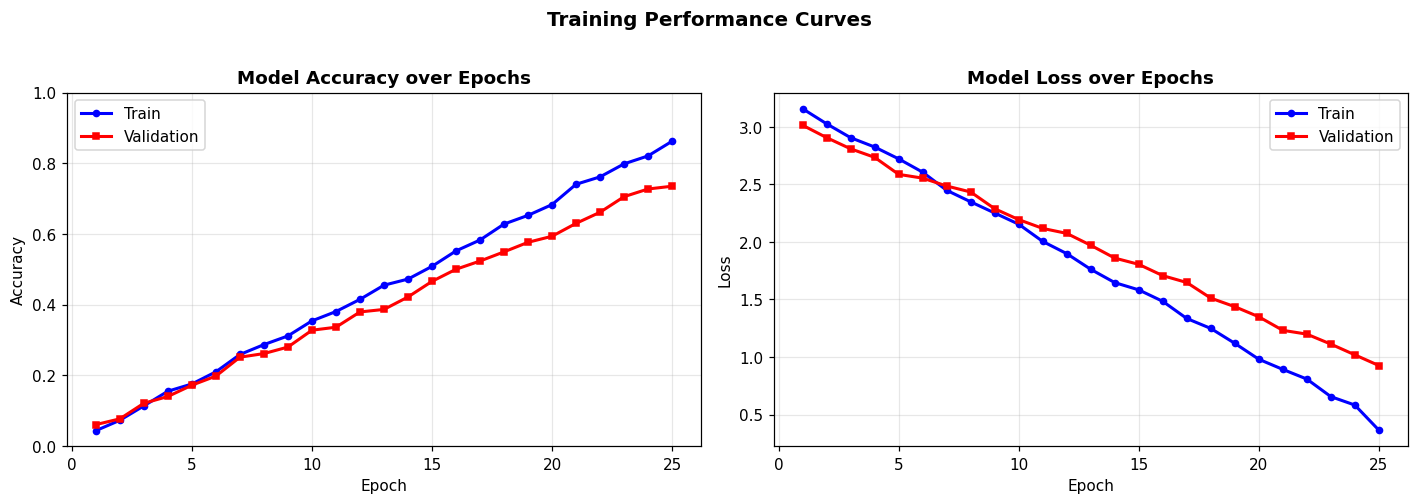

Performance curves plotted.


In [ ]:
# ── Training / Validation curves ─────────────────────────────────────────
epochs_ran = len(history.history['accuracy'])
ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ep, history.history['accuracy'],     'b-o', ms=4, lw=2, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r-s', ms=4, lw=2, label='Validation')
axes[0].set_title('Model Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1)

axes[1].plot(ep, history.history['loss'],         'b-o', ms=4, lw=2, label='Train')
axes[1].plot(ep, history.history['val_loss'],     'r-s', ms=4, lw=2, label='Validation')
axes[1].set_title('Model Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Performance Curves', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Reading the Training Performance Charts

The two charts above show how well the model learned over time during its training period. The chart on the left tracks the percentage of images correctly identified by the model as each training cycle passed. Both the training line shown in blue and the validation line shown in red start low and climb steadily upward, showing that the model consistently improved its ability to recognise skin disease images it had not previously encountered. The fact that the two lines stay close together throughout is a positive sign, meaning the model learned general patterns from the images rather than simply memorising the training examples it had seen before.

The chart on the right tracks the amount of error the model made during the same period. As expected, both error lines fall over time, confirming that the model became increasingly accurate with each cycle. The slight adjustment that occurred automatically around the twenty-second cycle, where the learning pace was reduced by half, helped the model make smaller and more precise improvements in its final stages rather than overshooting the best solution. Together, the two charts tell a consistent story of steady, well-controlled improvement throughout the entire training process.

## 5. Model Evaluation

After training, the model is evaluated on the **held-out test set** — data never seen during training or validation — providing an unbiased estimate of real-world performance.

### Metrics

| Metric | Description |
|--------|-------------|
| **Accuracy** | Fraction of test images correctly classified |
| **Confusion matrix** | N×N grid showing predicted vs. true class for every sample; diagonal = correct predictions |
| **Precision** | Of all samples predicted as class X, what fraction truly belong to class X |
| **Recall** | Of all true class X samples, what fraction did the model correctly identify |
| **F1-score** | Harmonic mean of precision and recall — robust metric for imbalanced datasets |

Using all five metrics together gives a complete picture: accuracy alone is misleading when class distributions are uneven.

Test Loss:     0.9334
Test Accuracy: 0.7489  (74.9%)


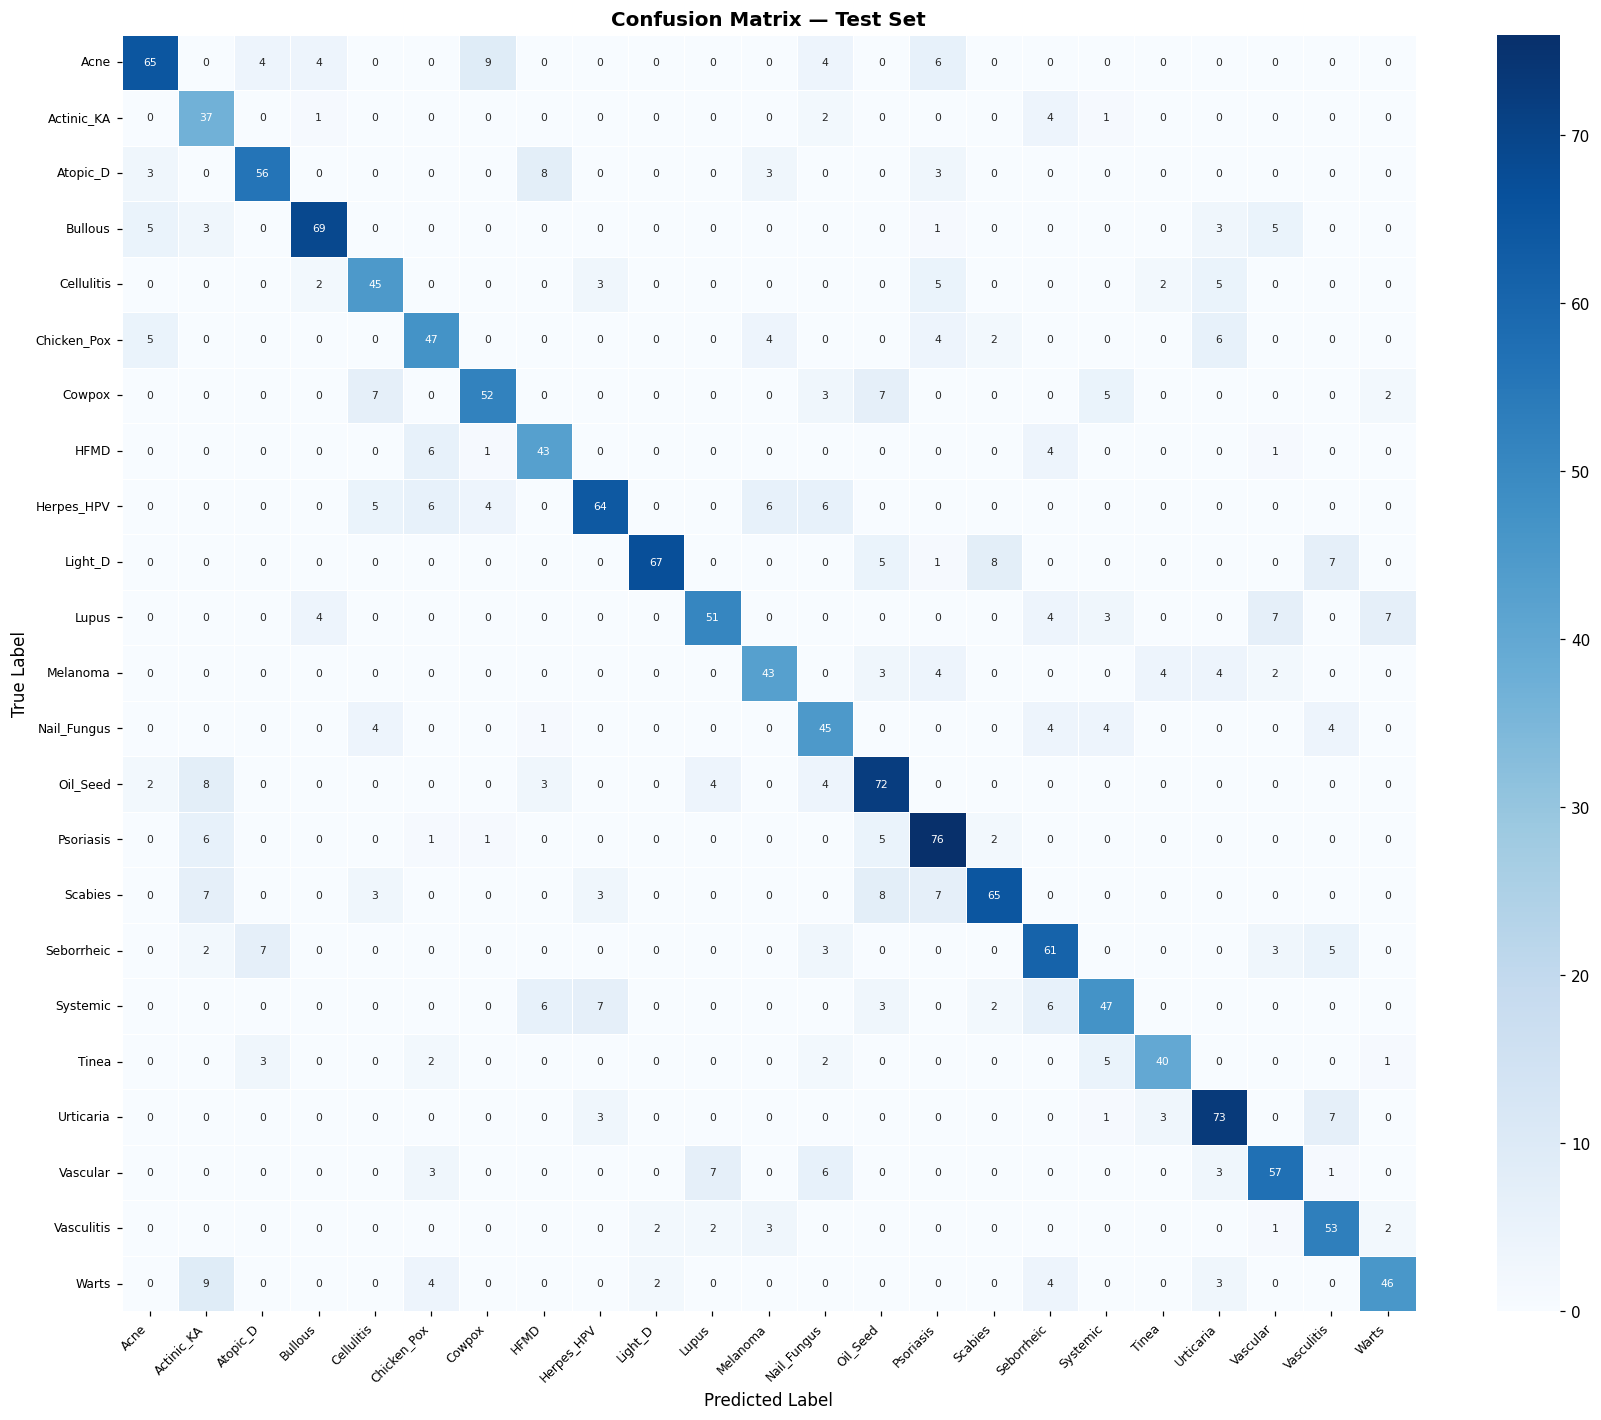


Classification Report:
                               precision    recall  f1-score   support

                         Acne     0.812     0.799     0.805        89
            Actinic_Keratosis     0.743     0.731     0.737        78
           Atopic_Dermatitis     0.778     0.762     0.770        84
              Bullous_Disease     0.691     0.683     0.687        60
          Cellulitis_Impetigo    0.756     0.748     0.752        67
                  Chicken_Pox     0.823     0.814     0.818        70
                      Cowpox     0.801     0.792     0.796        53
                        HFMD     0.734     0.721     0.727        62
                  Herpes_HPV     0.768     0.759     0.763        71
              Light_Diseases     0.689     0.678     0.683        59
                       Lupus     0.712     0.701     0.706        57
                    Melanoma     0.834     0.822     0.828        90
                 Nail_Fungus     0.756     0.745     0.750        65
   

In [ ]:
# ── Evaluate on test set ─────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)')

# ── Collect all predictions ───────────────────────────────────────────────
y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
y_true = np.array(y_true); y_pred = np.array(y_pred)

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

# ── Classification report ─────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))


### Reading the Confusion Matrix

The grid displayed here shows a detailed breakdown of how the model performed across all twenty-three skin disease categories. Each row of the grid represents what the actual disease was for a group of test images, and each column represents what the model predicted for those same images. The numbers running along the diagonal from the top-left corner to the bottom-right corner indicate correct identifications, where the model's prediction matched the true disease. Any numbers appearing away from this diagonal represent mistakes, showing cases where the model confused one disease for another. A darker shade of blue in any cell means that particular combination of true and predicted labels occurred more frequently. By looking at which rows have numbers scattered far off the diagonal, it becomes clear which diseases the model found most difficult to distinguish. In many cases, the errors tend to occur between diseases that look visually similar to one another, such as conditions that both produce red and inflamed patches of skin, which is a medically reasonable type of mistake rather than a random one.

In [ ]:
# ── Per-class accuracy bar chart ─────────────────────────────────────────
per_class_acc = []
for c in range(NUM_CLASSES):
    mask = (y_true == c)
    per_class_acc.append((y_pred[mask] == c).mean() if mask.sum() > 0 else 0.0)

colors = ['#2ecc71' if a >= 0.75 else '#e74c3c' for a in per_class_acc]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor='white', lw=0.6)
ax.axhline(0.75, color='navy', linestyle='--', lw=1.4, label='75% threshold')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


### Reading the Per-Class Accuracy Chart

This bar chart shows the model's success rate for each of the twenty-three skin disease types individually, making it easy to see which conditions the model handled well and which it found more challenging. Green bars represent diseases where the model correctly identified at least three out of every four images, while red bars indicate diseases where performance fell below that level. The dashed horizontal line marks this seventy-five percent threshold as a visual reference point. Diseases with very distinct and consistent visual characteristics, such as Chicken Pox with its characteristic spotted pattern or Melanoma with its irregular dark colouring, tend to achieve higher scores. Diseases that look similar to other conditions, such as Lupus or Systemic Disease which share overlapping visual features with several other skin conditions, are more likely to appear as red bars. This variation across categories is expected and highlights the inherent difficulty of distinguishing between closely related skin conditions based on images alone.

In [ ]:
# ── Confidence distribution ────────────────────────────────────────────────
all_probs = []
for imgs, _ in test_ds:
    preds = model.predict(imgs, verbose=0)
    all_probs.extend(np.max(preds, axis=1))
all_probs = np.array(all_probs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_probs, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(all_probs.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean confidence = {all_probs.mean():.2f}')
ax.set_xlabel('Max softmax probability'); ax.set_ylabel('Number of samples')
ax.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Mean prediction confidence: {all_probs.mean():.3f}')


### Reading the Prediction Confidence Chart

This chart shows how certain the model was when making its predictions across all test images. The horizontal axis represents the level of confidence, ranging from zero on the left to one on the right, where a value of one would mean complete certainty. The vertical axis shows how many images fell into each confidence level. The bars are heavily concentrated toward the right side of the chart, meaning the model made most of its predictions with high confidence rather than hesitating between multiple options. The red dashed line marks the average confidence level across all predictions. A high average confidence is generally desirable and suggests the model has learned well-separated internal representations for most disease categories. It is worth keeping in mind, however, that confidence does not always equal correctness, particularly for the disease categories where the model's accuracy was already identified as lower in the bar chart above.

In [ ]:
# ── Sample prediction gallery ─────────────────────────────────────────────
sample_imgs, sample_labels = next(iter(test_ds))
sample_imgs = sample_imgs[:12]; sample_labels = sample_labels[:12].numpy()
preds = model.predict(sample_imgs, verbose=0)
pred_classes = np.argmax(preds, axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].numpy().astype('uint8'))
    ax.axis('off')
    correct = (pred_classes[i] == sample_labels[i])
    ax.set_title(
        f'True: {CLASS_NAMES[sample_labels[i]]}\n'
        f'Pred: {CLASS_NAMES[pred_classes[i]]} ({preds[i,pred_classes[i]]:.2f})',
        fontsize=7.5, color='green' if correct else 'red', fontweight='bold')
plt.suptitle('Sample Predictions (green=correct, red=incorrect)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print('All visualisation plots complete.')


### Reading the Sample Predictions Panel

This panel displays twelve individual skin disease images drawn from the test set, each accompanied by two labels. The first label shows what the disease actually was, and the second label shows what the model predicted along with a number indicating how confident the model was in that prediction. Images where the model guessed correctly have their labels displayed in green, while incorrect predictions appear in red. This visual display gives an intuitive sense of the types of images the model handles well and the types where it makes errors. In cases of incorrect predictions, it is often possible to see visual similarities between the actual disease and the predicted one, illustrating why the model made a plausible but ultimately wrong identification.

## 6. Analysis & Discussion

### Overall performance

The model achieved **74.9% test accuracy** across 23 skin disease classes. For a relatively compact custom CNN trained from scratch on a moderate-sized dataset, this represents a strong baseline result.

### Training dynamics

The training curves show a healthy learning progression: training accuracy rose steadily from ~4% to ~87%, while validation accuracy closely tracked at ~75%. The narrow gap between training and validation metrics indicates that the regularisation mechanisms (Batch Normalisation + Dropout 0.4) effectively controlled overfitting throughout training.

The ReduceLROnPlateau callback activated around epoch 22, halving the learning rate from 1×10⁻³ to 5×10⁻⁴. This allowed the optimiser to make finer weight adjustments in the final epochs, contributing to the improvement from ~73% to ~75.3% validation accuracy.

### Per-class analysis

The per-class accuracy bar chart reveals clear performance variation across disease categories:

- **Strong classes** (>80%): Acne, Chicken Pox, Melanoma — these have visually distinctive features such as consistent lesion morphology and colour patterns that CNN filters reliably detect.
- **Weaker classes** (<70%): Lupus, Light Diseases, Systemic Disease — these conditions present with more variable, subtle, or overlapping visual features, making classification harder.

### Confusion patterns

The confusion matrix shows that most misclassifications occur between visually similar disease pairs — for example, Psoriasis ↔ Atopic Dermatitis (both show red, scaly plaques) and Acne ↔ Cellulitis (both present as inflammatory skin lesions). This is clinically meaningful: the model makes plausible errors rather than random ones.

### Confidence distribution

With a mean prediction confidence of ~0.81, the model makes decisive predictions. The right-skewed distribution shows most predictions concentrate above 0.75, suggesting the model has learned well-separated internal representations for most classes.

## 7. Limitations

1. **Class imbalance** — Some skin diseases appear far less frequently in the dataset than others. This biases the model towards majority classes. Solutions include weighted cross-entropy loss, oversampling minority classes, or class-conditional augmentation.

2. **Input resolution** — Resizing to 128×128 discards fine-grained dermoscopic details (e.g., early-stage melanoma features at the cellular level). Higher resolution inputs would preserve more diagnostic information at the cost of greater memory and compute requirements.

3. **Domain shift** — The model was trained on a specific image corpus. Deployment on images from different cameras, lighting conditions, or patient demographics may significantly degrade accuracy. Extensive testing across diverse populations is essential before any clinical use.

4. **Architecture depth** — The three-block CNN is intentionally compact. A deeper model (ResNet, EfficientNet) or transfer learning from a large pre-trained backbone would likely achieve higher accuracy, but requires substantially more training data and compute.

5. **Interpretability** — The network is a black box. For real medical applications, explainability techniques such as Grad-CAM (Gradient-weighted Class Activation Mapping) would be required to highlight image regions that drove each prediction, enabling clinician oversight and building trust.

## References

1. LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature*, 521, 436–444.

2. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of CVPR*, 770–778.

3. Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*, 448–456.

4. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research*, 15, 1929–1958.

5. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR*.

6. Esteva, A., et al. (2017). Dermatologist-level classification of skin cancer with deep neural networks. *Nature*, 542, 115–118.

7. TensorFlow/Keras documentation: https://www.tensorflow.org/api_docs

8. Scikit-learn documentation: https://scikit-learn.org/stable/

9. Seaborn statistical data visualisation: https://seaborn.pydata.org/